# FoodEx2 Matching Results — Analysis

Compares two matching runs and performs a deep analysis of the selected run (`BAAI/bge-small-en-v1.5`):

1. Coverage — ingredients processed and mapped
2. Run comparison (all-mpnet-base-v2 vs bge-small-en-v1.5)
3. Confidence level distribution
4. Matching route distribution and confidence by route
5. Score distributions
6. Match examples per confidence level
7. Export of 200 stratified ingredients for manual evaluation

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("..")
DATA = ROOT / "data"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

# ── Paths ──────────────────────────────────────────────────────────────────
MPNET_ING  = DATA / "matching_results_ingredients.parquet"
BGE_ING    = DATA / "matching_results_ingredients_baai__bge_small_en_v1_5.parquet"
BGE_PROD   = DATA / "matching_results_baai__bge_small_en_v1_5.parquet"
PI_PATH    = DATA / "products_ingredients.parquet"

# ── Load ───────────────────────────────────────────────────────────────────
mpnet = pd.read_parquet(MPNET_ING)
bge   = pd.read_parquet(BGE_ING)
prod  = pd.read_parquet(BGE_PROD)
pi    = pd.read_parquet(PI_PATH)

# Ordered confidence levels
CONF_ORDER  = ["HIGH", "MEDIUM", "LOW", "NO_MATCH"]
CONF_COLORS = {"HIGH": "#2ca02c", "MEDIUM": "#1f77b4", "LOW": "#ff7f0e", "NO_MATCH": "#d62728"}

for df, name in [(mpnet, 'mpnet'), (bge, 'bge')]:
    df['confidence'] = pd.Categorical(df['confidence'], categories=CONF_ORDER, ordered=True)

print("Data loaded.")
print(f"  all-mpnet-base-v2 ingredients : {len(mpnet):,}")
print(f"  bge-small-en-v1.5 ingredients : {len(bge):,}")
print(f"  bge-small product-level rows  : {len(prod):,}")
print(f"  products_ingredients rows     : {len(pi):,}")

: 

## 1. Coverage — ingredients processed and mapped

In [ ]:
# Total matchable ingredients in the source dataset
total_source = pi[pi["matchable"] == True]["ingredient"].nunique()

for label, df in [("all-mpnet-base-v2", mpnet), ("bge-small-en-v1.5 (selected)", bge)]:
    total     = len(df)
    matched   = (df["confidence"] != "NO_MATCH").sum()
    no_match  = (df["confidence"] == "NO_MATCH").sum()
    high      = (df["confidence"] == "HIGH").sum()
    medium    = (df["confidence"] == "MEDIUM").sum()
    low       = (df["confidence"] == "LOW").sum()

    print(f"\n{'─'*55}")
    print(f"  Run : {label}")
    print(f"{'─'*55}")
    print(f"  Unique matchable ingredients in source : {total_source:>7,}")
    print(f"  Unique ingredients processed           : {total:>7,}  ({100*total/total_source:.1f}%)")
    print(f"  Mapped (any level)                     : {matched:>7,}  ({100*matched/total:.1f}%)")
    print(f"    HIGH                                 : {high:>7,}  ({100*high/total:.1f}%)")
    print(f"    MEDIUM                               : {medium:>7,}  ({100*medium/total:.1f}%)")
    print(f"    LOW                                  : {low:>7,}  ({100*low/total:.1f}%)")
    print(f"  NO_MATCH                               : {no_match:>7,}  ({100*no_match/total:.1f}%)")


───────────────────────────────────────────────────────
  Run : all-mpnet-base-v2
───────────────────────────────────────────────────────
  Unique matchable ingredients in source :  24,128
  Unique ingredients processed           :  22,824  (94.6%)
  Mapped (any level)                     :   7,332  (32.1%)
    HIGH                                 :     617  (2.7%)
    MEDIUM                               :   2,753  (12.1%)
    LOW                                  :   3,962  (17.4%)
  NO_MATCH                               :  15,492  (67.9%)

───────────────────────────────────────────────────────
  Run : bge-small-en-v1.5 (selected)
───────────────────────────────────────────────────────
  Unique matchable ingredients in source :  24,128
  Unique ingredients processed           :  23,774  (98.5%)
  Mapped (any level)                     :  23,695  (99.7%)
    HIGH                                 :   1,265  (5.3%)
    MEDIUM                               :  15,194  (63.9%)
    LOW    

Total products in products_ingredients :  29,406
Products with >= 1 matchable ingredient :  29,120  (99.0%)

Products by best confidence level reached:
  HIGH          26,295  (90.6%)
  MEDIUM         2,605  (9.0%)
  LOW              122  (0.4%)
  NO_MATCH           1  (0.0%)
  ───────────────────────────────────
  Total        29,023


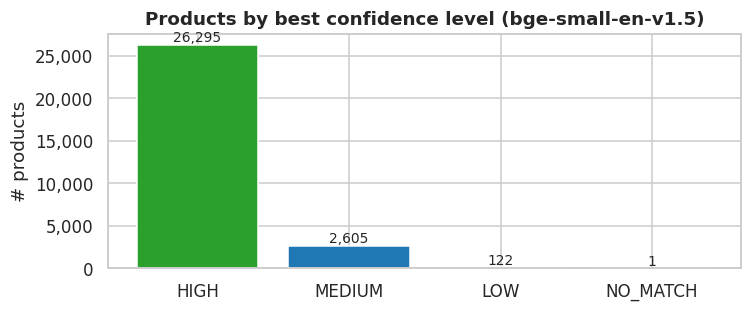

In [ ]:
# Products processed
total_products      = pi["code"].nunique()
matchable_products  = pi[pi["matchable"] == True]["code"].nunique()

# Products in the product-level join (has confidence column after the left join)
prod_conf = prod[["code", "confidence"]].copy()
prod_conf["confidence"] = prod_conf["confidence"].fillna("unmatched")

any_match  = prod[prod["confidence"].notna() & (prod["confidence"] != "NO_MATCH")]["code"].nunique()
all_no_match = prod[
    prod.groupby("code")["confidence"]
    .transform(lambda s: (s.fillna("NO_MATCH") == "NO_MATCH").all())
]["code"].nunique()

print(f"Total products in products_ingredients : {total_products:>7,}")
print(f"Products with >= 1 matchable ingredient : {matchable_products:>7,}  ({100*matchable_products/total_products:.1f}%)")
print()

# Per-product best confidence (highest reached)
conf_rank = {"HIGH": 3, "MEDIUM": 2, "LOW": 1, "NO_MATCH": 0}
prod_best = (
    prod[prod["matchable"] == True]
    .dropna(subset=["confidence"])
    .assign(conf_rank=lambda d: d["confidence"].map(conf_rank))
    .sort_values("conf_rank", ascending=False)
    .groupby("code", sort=False)["confidence"]
    .first()
    .reset_index()
)

prod_conf_dist = prod_best["confidence"].value_counts().reindex(CONF_ORDER, fill_value=0)
total_matched_products = len(prod_best)

print("Products by best confidence level reached:")
for conf, n in prod_conf_dist.items():
    print(f"  {conf:<12} {n:>7,}  ({100*n/total_matched_products:.1f}%)")
print(f"  {'─'*35}")
print(f"  Total       {total_matched_products:>7,}")

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
colors = [CONF_COLORS[c] for c in CONF_ORDER]
bars = ax.bar(CONF_ORDER, prod_conf_dist.values, color=colors, edgecolor="white")
for bar, val in zip(bars, prod_conf_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Products by best confidence level (bge-small-en-v1.5)", fontweight="bold")
ax.set_ylabel("# products")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(RESULTS / "products_by_confidence.png", bbox_inches="tight")
plt.show()

Products with >= 1 matched ingredient : 29,009

Average path_score statistics across products:
count    29009.0000
mean         0.8023
std          0.0339
min          0.2518
25%          0.7907
50%          0.8074
75%          0.8209
max          0.8933

Top 10 best-covered products (highest avg path score):


,product_name,n_ingredients,avg_path_score,n_high,n_medium,n_low
0,Full Cream Pure Milk,2,0.893331,2,0,0
1,Full Cream Long Life Milk,2,0.893331,2,0,0
2,Le bon lait de vache entier,2,0.893302,2,0,0
3,Magnolia Fresh Milk,2,0.893302,2,0,0
4,Fresh Full Cream Milk,2,0.893302,2,0,0
5,High Protein Paneer,2,0.893302,2,0,0
6,Petit frais,3,0.888888,3,0,0
7,Le bon brie,3,0.888868,3,0,0
8,President carre bridel familial 350g,3,0.888868,3,0,0
9,"Modern farms, dried mushrooms, meaty texture",1,0.887323,1,0,0



10 worst-covered products (lowest avg path score):


,product_name,n_ingredients,avg_path_score,n_high,n_medium,n_low
0,full cream milk,4,0.506676,0,0,4
1,Breakfast Blend tea bags,7,0.502136,1,0,6
2,Wild caught mahi mahi fillets,2,0.498456,0,0,2
3,StillHead Rhubarb Gin,1,0.494302,0,0,1
4,Veggie delight pizza 420gm,3,0.479128,0,0,3
5,pepsi max,2,0.466559,0,0,2
6,Br МОЁ HANDON MOET & CHANDON CHAMPAGNE IMPERIA...,3,0.428338,0,0,3
7,Cerveza Royal Guard (CCU),5,0.400818,0,0,5
8,ketchup,1,0.255861,0,0,1
9,Croissant aux abricots.,1,0.251816,0,0,1


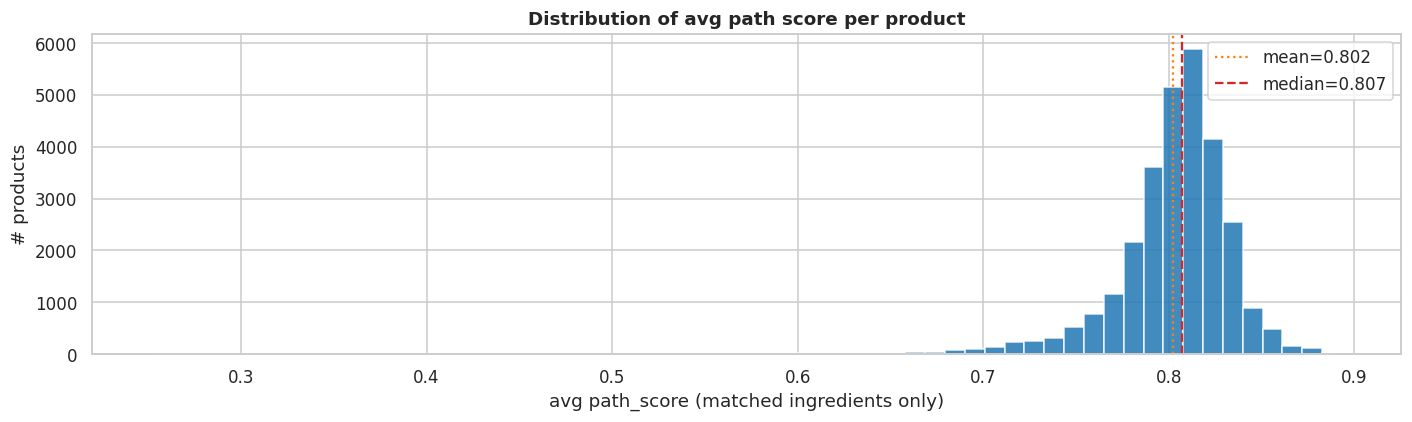

In [ ]:
# Average confidence score per product
# Uses path_score (continuous, 0-1) as the numeric confidence measure.
# Only matchable ingredients with a path_score are included (NO_MATCH rows
# have path_score == 0 and are excluded so they don't drag the mean down
# for products that have other successfully matched ingredients).

matchable_scored = (
    prod[
        (prod["matchable"] == True) &
        (prod["path_score"].notna()) &
        (prod["confidence"] != "NO_MATCH")
    ]
    [["code", "product_name", "ingredient", "confidence", "path_score"]]
    .copy()
)

product_avg = (
    matchable_scored
    .groupby(["code", "product_name"], sort=False)
    .agg(
        n_ingredients   = ("ingredient",  "count"),
        avg_path_score  = ("path_score",  "mean"),
        min_path_score  = ("path_score",  "min"),
        max_path_score  = ("path_score",  "max"),
        n_high          = ("confidence",  lambda s: (s == "HIGH").sum()),
        n_medium        = ("confidence",  lambda s: (s == "MEDIUM").sum()),
        n_low           = ("confidence",  lambda s: (s == "LOW").sum()),
    )
    .reset_index()
    .sort_values("avg_path_score", ascending=False)
)

print(f"Products with >= 1 matched ingredient : {len(product_avg):,}")
print(f"\nAverage path_score statistics across products:")
print(product_avg["avg_path_score"].describe().round(4).to_string())

print(f"\nTop 10 best-covered products (highest avg path score):")
display(
    product_avg.head(10)[["product_name", "n_ingredients",
                           "avg_path_score", "n_high", "n_medium", "n_low"]]
    .reset_index(drop=True)
)

print(f"\n10 worst-covered products (lowest avg path score):")
display(
    product_avg.tail(10)[["product_name", "n_ingredients",
                           "avg_path_score", "n_high", "n_medium", "n_low"]]
    .reset_index(drop=True)
)

# Distribution plot
fig, ax = plt.subplots(figsize=(13, 4))

ax.hist(product_avg["avg_path_score"], bins=60,
             color="#1f77b4", edgecolor="white", alpha=0.85)
ax.axvline(product_avg["avg_path_score"].mean(),   color="#ff7f0e",
                linestyle=":",  linewidth=1.5,
                label=f"mean={product_avg['avg_path_score'].mean():.3f}")
ax.axvline(product_avg["avg_path_score"].median(), color="#d62728",
                linestyle="--", linewidth=1.5,
                label=f"median={product_avg['avg_path_score'].median():.3f}")
ax.set_title("Distribution of avg path score per product", fontweight="bold")
ax.set_xlabel("avg path_score (matched ingredients only)")
ax.set_ylabel("# products")
ax.legend()


plt.tight_layout()
plt.savefig(RESULTS / "avg_score_per_product.png", bbox_inches="tight")
plt.show()

## 2. Run comparison

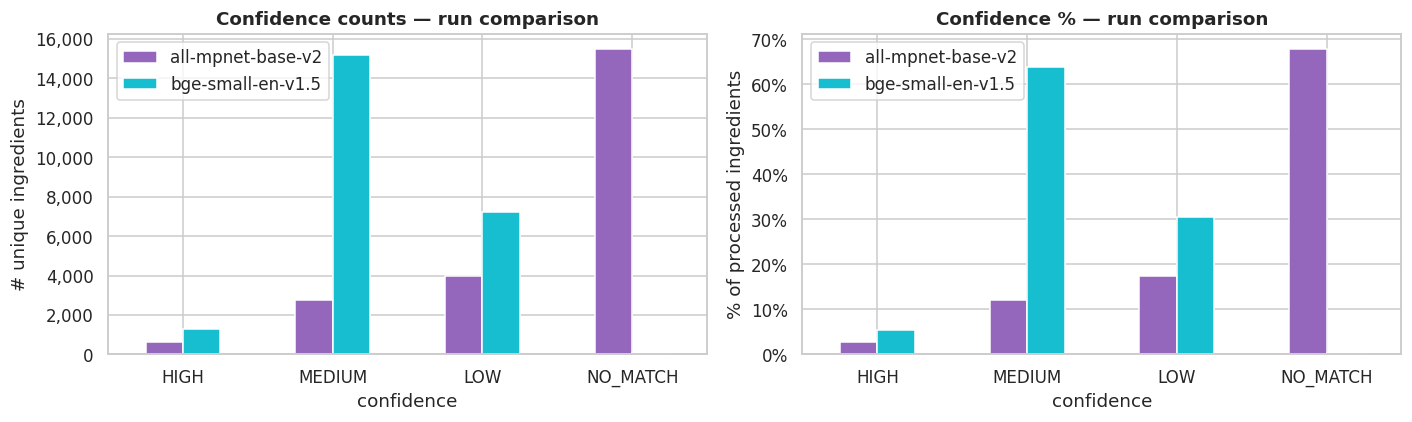


Absolute counts:
            all-mpnet-base-v2  bge-small-en-v1.5
confidence                                      
HIGH                      617               1265
MEDIUM                   2753              15194
LOW                      3962               7236
NO_MATCH                15492                 79

Percentages:
            all-mpnet-base-v2  bge-small-en-v1.5
confidence                                      
HIGH                      2.7                5.3
MEDIUM                   12.1               63.9
LOW                      17.4               30.4
NO_MATCH                 67.9                0.3


In [ ]:
# Side-by-side confidence counts
comp = pd.DataFrame({
    "all-mpnet-base-v2":    mpnet["confidence"].value_counts().reindex(CONF_ORDER, fill_value=0),
    "bge-small-en-v1.5":   bge["confidence"].value_counts().reindex(CONF_ORDER, fill_value=0),
})

comp_pct = comp.div(comp.sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

comp.plot(kind="bar", ax=axes[0], color=["#9467bd", "#17becf"], rot=0, edgecolor="white")
axes[0].set_title("Confidence counts — run comparison", fontweight="bold")
axes[0].set_ylabel("# unique ingredients")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend()

comp_pct.plot(kind="bar", ax=axes[1], color=["#9467bd", "#17becf"], rot=0, edgecolor="white")
axes[1].set_title("Confidence % — run comparison", fontweight="bold")
axes[1].set_ylabel("% of processed ingredients")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / "run_comparison.png", bbox_inches="tight")
plt.show()

print("\nAbsolute counts:")
print(comp.to_string())
print("\nPercentages:")
print(comp_pct.round(1).to_string())

In [ ]:
# Score comparison (path_score only exists in bge run; compare level scores for both)
score_cols_common = ["level2_score", "level3_score", "specific_score"]

print("Score statistics — all-mpnet-base-v2 (mapped only):")
print(mpnet[mpnet["confidence"] != "NO_MATCH"][score_cols_common].describe().round(4).to_string())

print("\nScore statistics — bge-small-en-v1.5 (mapped only):")
print(bge[bge["confidence"] != "NO_MATCH"][score_cols_common + ["path_score"]].describe().round(4).to_string())

Score statistics — all-mpnet-base-v2 (mapped only):
       level2_score  level3_score  specific_score
count     7332.0000     7332.0000       7332.0000
mean         0.5244        0.5492          0.2812
std          0.0621        0.0953          0.3333
min          0.4500        0.2308          0.0000
25%          0.4755        0.4836          0.0000
50%          0.5095        0.5402          0.0000
75%          0.5584        0.6097          0.6225
max          0.9506        1.0000          1.0000

Score statistics — bge-small-en-v1.5 (mapped only):
       level2_score  level3_score  specific_score  path_score
count    23695.0000    23695.0000      23695.0000  23695.0000
mean         0.7702        0.7557          0.6451      0.7168
std          0.1077        0.1521          0.2379      0.0977
min          0.3935        0.0000          0.0000      0.2205
25%          0.7172        0.7123          0.6313      0.6827
50%          0.7845        0.7835          0.7251      0.7317
75%        

## 3. Confidence level distribution — selected run (bge-small-en-v1.5)

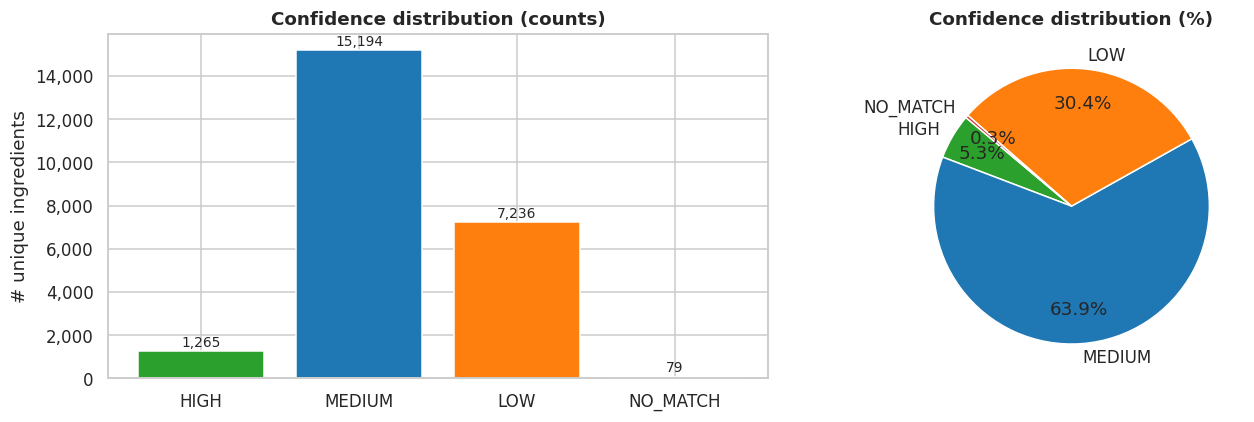

            count   pct  cumulative_pct
confidence                             
HIGH         1265   5.3             5.3
MEDIUM      15194  63.9            69.2
LOW          7236  30.4            99.6
NO_MATCH       79   0.3            99.9


In [ ]:
conf_counts = bge["confidence"].value_counts().reindex(CONF_ORDER)
conf_pct    = conf_counts / conf_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = [CONF_COLORS[c] for c in CONF_ORDER]
bars = axes[0].bar(CONF_ORDER, conf_counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, conf_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Confidence distribution (counts)", fontweight="bold")
axes[0].set_ylabel("# unique ingredients")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

wedges, texts, autotexts = axes[1].pie(
    conf_counts.values, labels=CONF_ORDER,
    autopct="%1.1f%%", colors=colors,
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white")
)
axes[1].set_title("Confidence distribution (%)", fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS / "confidence_distribution.png", bbox_inches="tight")
plt.show()

summary = pd.DataFrame({"count": conf_counts, "pct": conf_pct.round(1)})
summary["cumulative_pct"] = summary["pct"].cumsum().round(1)
print(summary.to_string())

## 4. Matching route distribution and confidence by route

In [ ]:
# Overall route distribution
route_counts = bge["matching_mode"].value_counts()
route_pct    = route_counts / route_counts.sum() * 100

print("Matching route distribution:")
for route, cnt in route_counts.items():
    print(f"  {route:<20} {cnt:>7,}  ({route_pct[route]:.1f}%)")

print(f"\n  Of RF routes, exact variant matches: {bge['exact_variant_match'].sum():,}")

Matching route distribution:
  rf_reranked           22,999  (96.7%)
  rf_exact                 436  (1.8%)
  beam                     339  (1.4%)

  Of RF routes, exact variant matches: 436


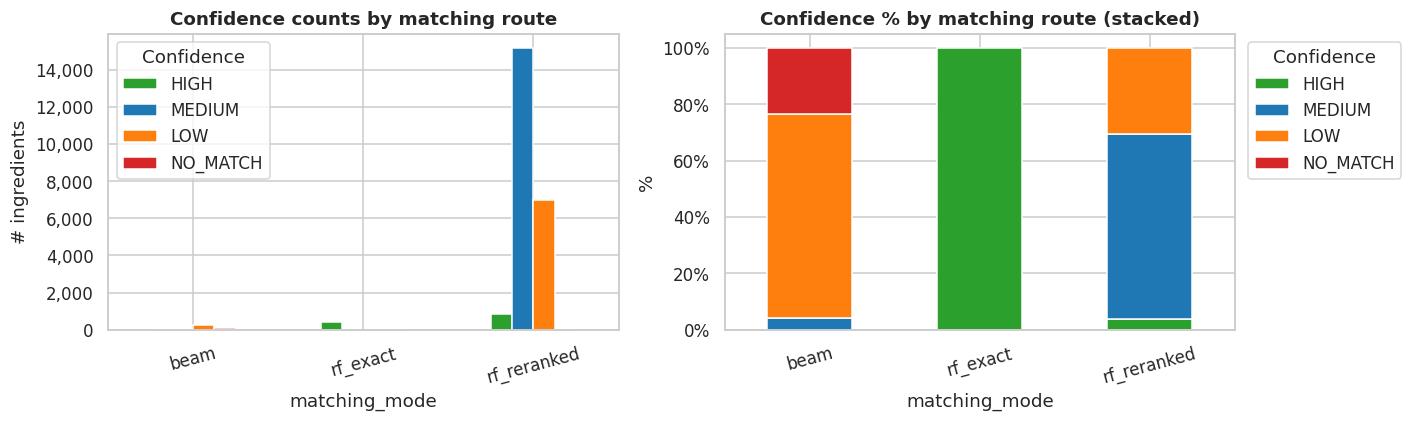


Confidence counts by matching route:
confidence     HIGH  MEDIUM   LOW  NO_MATCH
matching_mode                              
beam              0      14   246        79
rf_exact        436       0     0         0
rf_reranked     829   15180  6990         0

Confidence % by matching route:
confidence      HIGH  MEDIUM   LOW  NO_MATCH
matching_mode                               
beam             0.0     4.1  72.6      23.3
rf_exact       100.0     0.0   0.0       0.0
rf_reranked      3.6    66.0  30.4       0.0


In [ ]:
# Confidence breakdown by matching route
route_conf = (
    bge.groupby(["matching_mode", "confidence"], observed=True)
    .size()
    .unstack("confidence", fill_value=0)
    .reindex(columns=CONF_ORDER, fill_value=0)
)
route_conf_pct = route_conf.div(route_conf.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

route_conf.plot(kind="bar", ax=axes[0],
                color=[CONF_COLORS[c] for c in CONF_ORDER], rot=15, edgecolor="white")
axes[0].set_title("Confidence counts by matching route", fontweight="bold")
axes[0].set_ylabel("# ingredients")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="Confidence")

route_conf_pct.plot(kind="bar", ax=axes[1], stacked=True,
                    color=[CONF_COLORS[c] for c in CONF_ORDER], rot=15, edgecolor="white")
axes[1].set_title("Confidence % by matching route (stacked)", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].legend(title="Confidence", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig(RESULTS / "confidence_by_route.png", bbox_inches="tight")
plt.show()

print("\nConfidence counts by matching route:")
print(route_conf.to_string())
print("\nConfidence % by matching route:")
print(route_conf_pct.round(1).to_string())

In [ ]:
# Score statistics by route
print("Average scores by matching route:")
print(
    bge.groupby("matching_mode")[["bge_score", "rf_score", "lexical_score", "path_score"]]
    .mean().round(4).to_string()
)

Average scores by matching route:
               bge_score  rf_score  lexical_score  path_score
matching_mode                                                
beam              0.0000    0.0000         0.0000      0.2049
rf_exact          0.9962  100.0000         0.9450      0.8726
rf_reranked       0.7678   84.2496         0.2413      0.7189


## 5. Score distributions

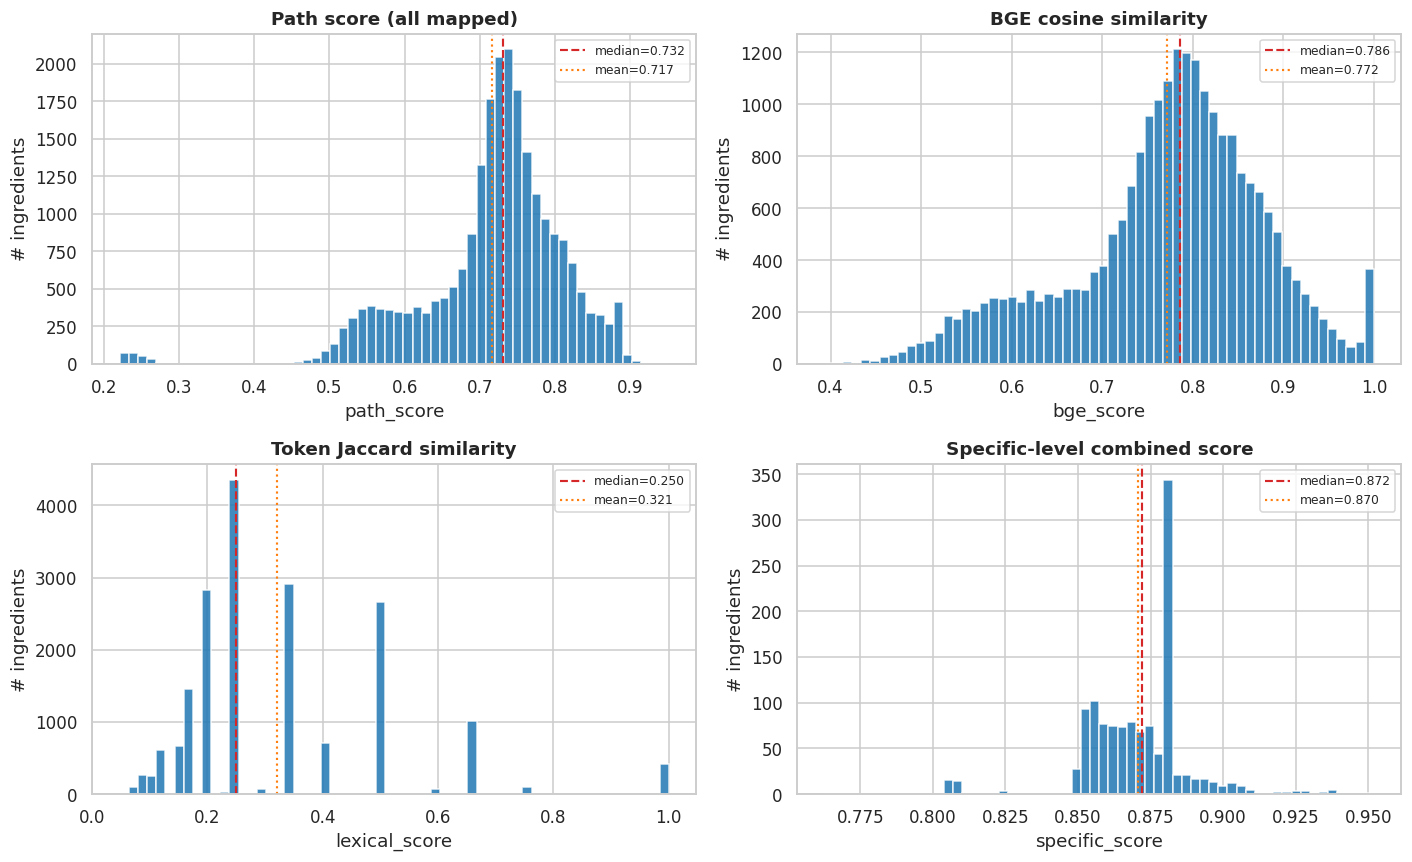

In [ ]:
mapped = bge[bge["confidence"] != "NO_MATCH"].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

score_defs = [
    ("path_score",     "Path score (all mapped)",       mapped,                              axes[0, 0]),
    ("bge_score",      "BGE cosine similarity",          mapped,                              axes[0, 1]),
    ("lexical_score",  "Token Jaccard similarity",       mapped,                              axes[1, 0]),
    ("specific_score", "Specific-level combined score",  mapped[mapped["confidence"]=="HIGH"], axes[1, 1]),
]

for col, title, data, ax in score_defs:
    if data.empty or col not in data.columns:
        ax.set_visible(False)
        continue
    vals = data[col].dropna()
    vals = vals[vals > 0]
    ax.hist(vals, bins=60, color="#1f77b4", edgecolor="white", alpha=0.85)
    ax.axvline(vals.median(), color="#d62728", linestyle="--", linewidth=1.4, label=f"median={vals.median():.3f}")
    ax.axvline(vals.mean(),   color="#ff7f0e", linestyle=":",  linewidth=1.4, label=f"mean={vals.mean():.3f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("# ingredients")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "score_distributions.png", bbox_inches="tight")
plt.show()

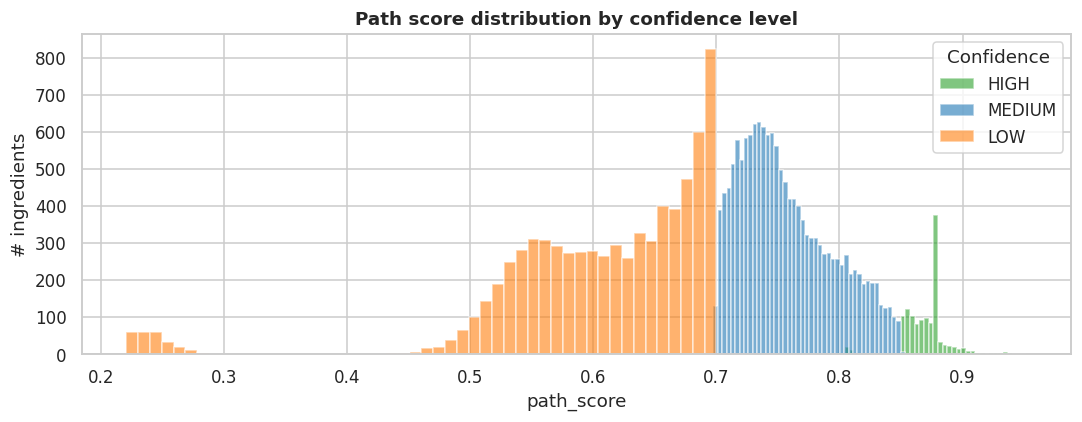

In [ ]:
# Path score distribution split by confidence level
fig, ax = plt.subplots(figsize=(10, 4))

for conf in ["HIGH", "MEDIUM", "LOW"]:
    vals = bge[bge["confidence"] == conf]["path_score"].dropna()
    vals = vals[vals > 0]
    ax.hist(vals, bins=50, alpha=0.6, label=conf, color=CONF_COLORS[conf], edgecolor="white")

ax.set_title("Path score distribution by confidence level", fontweight="bold")
ax.set_xlabel("path_score")
ax.set_ylabel("# ingredients")
ax.legend(title="Confidence")
plt.tight_layout()
plt.savefig(RESULTS / "path_score_by_confidence.png", bbox_inches="tight")
plt.show()

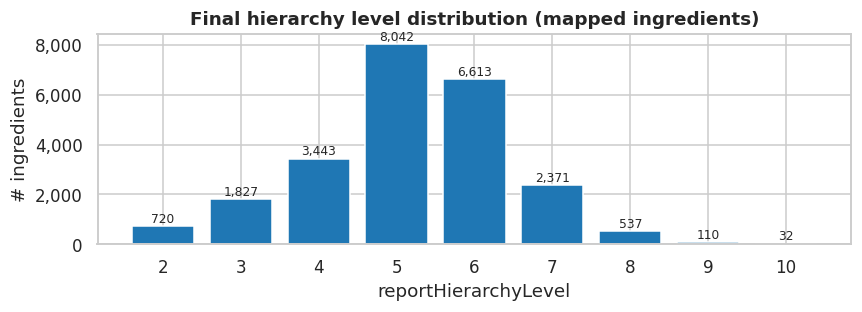

In [ ]:
# Hierarchical level distribution
level_counts = bge[bge["confidence"] != "NO_MATCH"]["final_level"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(level_counts.index.astype(str), level_counts.values, color="#1f77b4", edgecolor="white")
for bar, val in zip(bars, level_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("Final hierarchy level distribution (mapped ingredients)", fontweight="bold")
ax.set_xlabel("reportHierarchyLevel")
ax.set_ylabel("# ingredients")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(RESULTS / "final_level_distribution.png", bbox_inches="tight")
plt.show()

## 6. Match examples per confidence level

In [ ]:
DISPLAY_COLS = [
    "ingredient", "level2_name", "level3_name",
    "specific_name", "specific_score", "path_score",
    "matching_mode", "final_level", "confidence"
]

pd.set_option("display.max_colwidth", 45)
pd.set_option("display.max_rows", 20)

for conf in CONF_ORDER:
    subset = bge[bge["confidence"] == conf]
    print(f"\n{'='*80}")
    print(f"  {conf}  —  {len(subset):,} ingredients")
    print(f"{'='*80}")
    sample = subset.sample(min(15, len(subset)), random_state=42)[DISPLAY_COLS]
    display(sample.reset_index(drop=True))


  HIGH  —  1,265 ingredients


,ingredient,level2_name,level3_name,specific_name,specific_score,path_score,matching_mode,final_level,confidence
0,whole egg,Eggs and egg products,Whole eggs,None,0.000000,0.885502,rf_reranked,3,HIGH
1,water tomato paste,Garden vegetables and primary derivatives...,Processed or preserved vegetables and sim...,Tomato paste,0.868004,0.868004,rf_reranked,6,HIGH
2,fresh milk,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Fresh milk flavour,0.856491,0.856491,rf_reranked,6,HIGH
3,vanilla flavour cream,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Vanilla flavour,0.865617,0.865617,rf_reranked,6,HIGH
4,propellent gas,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Propellent gas,0.880000,0.880000,rf_exact,5,HIGH
5,parsley cherry tomatoes,Garden vegetables and primary derivatives...,Fruiting vegetables,Cherry tomatoes,0.867014,0.867014,rf_reranked,7,HIGH
6,amaretto flavor,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Amaretto flavour,0.808828,0.808828,rf_exact,6,HIGH
7,flavouring flour treatment agent,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Flour treatment agent,0.863205,0.863205,rf_reranked,5,HIGH
8,apricot jam,"Fruit/vegetables/plant drinks, spreads an...",Fruit / vegetable spreads and similar,"Jam, apricots",0.862587,0.862587,rf_reranked,5,HIGH
9,liquid egg white,Eggs and egg products,Liquid egg products,Egg white,0.869345,0.869345,rf_reranked,4,HIGH



  MEDIUM  —  15,194 ingredients


,ingredient,level2_name,level3_name,specific_name,specific_score,path_score,matching_mode,final_level,confidence
0,natural peach flavouring,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Peach flavour,0.807470,0.807470,rf_reranked,6,MEDIUM
1,soybean oil blend,Isolated purified ingredients (including ...,Animal and vegetable fats and oils and pr...,"Soya bean oil, refined",0.735242,0.735242,rf_reranked,7,MEDIUM
2,vietnamese ground cinnamon,"Herbs, spices and similar",Aromatic herbs,Vietnamese mint,0.740775,0.740775,rf_reranked,5,MEDIUM
3,wheat wrap,Grains and grain-based products,Cereal grains and similar and primary der...,Wheat rolled grains,0.746858,0.746858,rf_reranked,6,MEDIUM
4,palm base,Garden vegetables and primary derivatives...,Stems/stalks eaten as vegetables,Palm hearts and similar-,0.705022,0.705022,rf_reranked,4,MEDIUM
5,natural arem,"Water, water-based beverages and related ...",Drinking water,Natural mineral water,0.741227,0.741227,rf_reranked,5,MEDIUM
6,its products,Seafood and products thereof,None,None,0.000000,0.728507,rf_reranked,2,MEDIUM
7,starch batter,Composite dishes,"Fried or extruded cereal, seed or root-ba...",Potato starch-based snacks,0.721148,0.721148,rf_reranked,5,MEDIUM
8,vitamin b1 b,Isolated purified ingredients (including ...,Ingredients for food fortification/enrich...,Vitamin B1 (thiamine),0.803069,0.803069,rf_reranked,5,MEDIUM
9,cyanocabalamin,Isolated purified ingredients (including ...,Ingredients for food fortification/enrich...,"Vitamin B12 (cyanocobalamin, hydroxocobal...",0.746272,0.746272,rf_reranked,5,MEDIUM



  LOW  —  7,236 ingredients


,ingredient,level2_name,level3_name,specific_name,specific_score,path_score,matching_mode,final_level,confidence
0,smohe flavo produced from hichory,Alcoholic beverages,Unsweetened spirits,Spirits from fruit,0.664093,0.664093,rf_reranked,4,LOW
1,bechamel light,"Seasoning, sauces and condiments",Condiments (including table-top formats),Bechamel sauce,0.671560,0.671560,rf_reranked,6,LOW
2,feuilletine wafer,Grains and grain-based products,Cereal dough-based products,Wafers,0.676240,0.676240,rf_reranked,8,LOW
3,surhetsreglerande medel,Nuts and primary derivatives thereof,Primary derivatives from nuts and similar...,None,0.000000,0.238439,beam,2,LOW
4,mechanically separatedturkey,Mammals and birds meat and products thereof,Animal mechanically separated meat (MSM),None,0.000000,0.605044,rf_reranked,3,LOW
5,cacaoa,"Hot drinks and similar (coffee, cocoa, te...",Cocoa beverages,None,0.000000,0.654160,rf_reranked,3,LOW
6,carne asada seasoning,"Seasoning, sauces and condiments",Seasoning mixes,None,0.000000,0.697370,rf_reranked,3,LOW
7,uncured pepperoni,Mammals and birds meat and products thereof,Processed or preserved meat,Pepperoni/paprika-type sausage,0.690719,0.690719,rf_reranked,8,LOW
8,colza oil,Isolated purified ingredients (including ...,Animal and vegetable fats and oils and pr...,Grape seed oil,0.685285,0.685285,rf_reranked,7,LOW
9,weat froar,Grains and grain-based products,Cereal grains and similar and primary der...,Buckwheat groats,0.554344,0.554344,rf_reranked,6,LOW



  NO_MATCH  —  79 ingredients


,ingredient,level2_name,level3_name,specific_name,specific_score,path_score,matching_mode,final_level,confidence
0,kadayif,Composite dishes,None,None,0.0,0.0,beam,2,NO_MATCH
1,01 kmov hh nupublika,Fruit and primary derivatives thereof,None,None,0.0,0.0,beam,2,NO_MATCH
2,gekocht,Alcoholic beverages,None,None,0.0,0.0,beam,2,NO_MATCH
3,kangkong,Terrestrial animals other than mammals an...,None,None,0.0,0.0,beam,2,NO_MATCH
4,ernest jackson,Nuts and primary derivatives thereof,None,None,0.0,0.0,beam,2,NO_MATCH
5,javentry,Meat and dairy imitates,None,None,0.0,0.0,beam,2,NO_MATCH
6,cebolla prezzemolo,"Herbs, spices and similar",None,None,0.0,0.0,beam,2,NO_MATCH
7,uvi ursi,Composite dishes,None,None,0.0,0.0,beam,2,NO_MATCH
8,5 wo liu hang road,Garden vegetables and primary derivatives...,None,None,0.0,0.0,beam,2,NO_MATCH
9,dekstroz,Nuts and primary derivatives thereof,None,None,0.0,0.0,beam,2,NO_MATCH


In [ ]:
# Top-20 HIGH by path score
print("Top 20 HIGH-confidence matches by path score:")
top_high = (
    bge[bge["confidence"] == "HIGH"]
    .nlargest(20, "path_score")[DISPLAY_COLS]
    .reset_index(drop=True)
)
display(top_high)

Top 20 HIGH-confidence matches by path score:


,ingredient,level2_name,level3_name,specific_name,specific_score,path_score,matching_mode,final_level,confidence
0,yolk egg,Eggs and egg products,Liquid egg products,Egg yolk,0.951907,0.951907,rf_reranked,4,HIGH
1,long grain rice,Grains and grain-based products,Cereal grains and similar and primary der...,"Rice grain, long-grain",0.939865,0.939865,rf_reranked,7,HIGH
2,truffles summer,Garden vegetables and primary derivatives...,Fungi,Summer truffles,0.936896,0.936896,rf_reranked,6,HIGH
3,semolina wheat,Grains and grain-based products,Cereal grains and similar and primary der...,Wheat semolina,0.936543,0.936543,rf_reranked,6,HIGH
4,cane sugar molasses,Isolated purified ingredients (including ...,Sugars and similar,Sugar cane molasses,0.936431,0.936431,rf_reranked,6,HIGH
5,white wheat flour,Grains and grain-based products,Cereal grains and similar and primary der...,Wheat flour white,0.936150,0.936150,rf_reranked,7,HIGH
6,wine wine,Alcoholic beverages,Wine and wine-like drinks,Wine,0.935782,0.935782,rf_reranked,4,HIGH
7,fruit cardamom,"Herbs, spices and similar",Fruit spices,Cardamom fruit,0.934169,0.934169,rf_reranked,5,HIGH
8,almonds almonds,Nuts and primary derivatives thereof,Tree nuts,Almonds,0.929302,0.929302,rf_reranked,5,HIGH
9,cane brown sugar,Isolated purified ingredients (including ...,Sugars and similar,Brown cane sugar,0.929298,0.929298,rf_reranked,7,HIGH


In [ ]:
# Exact variant matches (rf_exact route)
print("Exact variant match examples:")
exact = bge[bge["exact_variant_match"] == True].sample(min(15, bge["exact_variant_match"].sum()), random_state=42)
display(exact[["ingredient", "rf_matched_variant", "level2_name", "level3_name",
               "specific_name", "path_score", "confidence"]].reset_index(drop=True))

Exact variant match examples:


,ingredient,rf_matched_variant,level2_name,level3_name,specific_name,path_score,confidence
0,vanilla,vanilla,"Herbs, spices and similar",Fruit spices,Vanilla,0.880000,HIGH
1,cassava flour,cassava flour,Starchy roots and tubers and primary deri...,Starchy root and tuber products,Cassava flour,0.880000,HIGH
2,paprika powder,paprika powder,"Herbs, spices and similar",Fruit spices,Paprika powder,0.880000,HIGH
3,pretzels,pretzels,Grains and grain-based products,Cereal dough-based products,Pretzels,0.880000,HIGH
4,rooibos,rooibos,Ingredients for hot drinks and infusions,Leaves used for infusions or hot drinks,Rooibos,0.880000,HIGH
5,pili nuts,pili nuts,Nuts and primary derivatives thereof,Tree nuts,Pili nuts,0.880000,HIGH
6,liquorice extract,liquorice extract,Isolated purified ingredients (including ...,"Major isolated ingredients, additives, fl...",Liquorice extract,0.880000,HIGH
7,cheese,cheese,Milk and milk products (dairy),Cheese,None,0.880000,HIGH
8,yeast extract,yeast extract,"Seasoning, sauces and condiments",Savoury extracts and sauce ingredients,Yeast extract,0.880000,HIGH
9,wakame,wakame,Garden vegetables and primary derivatives...,Plants where the vegetative tissue is use...,Wakame,0.880000,HIGH


In [ ]:
# NO_MATCH: show best L2 candidates that were still below threshold
print("NO_MATCH examples — best L2 candidates:")
no_match = bge[bge["confidence"] == "NO_MATCH"].sample(min(15, (bge["confidence"]=="NO_MATCH").sum()), random_state=42)
display(no_match[["ingredient", "top1_name", "top1_score",
                   "top2_name", "top2_score",
                   "top3_name", "top3_score"]].reset_index(drop=True))

NO_MATCH examples — best L2 candidates:


,ingredient,top1_name,top1_score,top2_name,top2_score,top3_name,top3_score
0,kadayif,Composite dishes,0.545348,Legume seeds and primary derivatives thereof,0.539447,Fruit and primary derivatives thereof,0.531029
1,01 kmov hh nupublika,Fruit and primary derivatives thereof,0.537922,Nuts and primary derivatives thereof,0.525040,Ingredients for hot drinks and infusions,0.517339
2,gekocht,Alcoholic beverages,0.549934,Fruit and primary derivatives thereof,0.522063,Composite dishes,0.521556
3,kangkong,Terrestrial animals other than mammals an...,0.502554,Garden vegetables and primary derivatives...,0.501386,Sugar plants,0.498886
4,ernest jackson,Nuts and primary derivatives thereof,0.463856,Isolated purified ingredients (including ...,0.459114,"Herbs, spices and similar",0.455081
5,javentry,Meat and dairy imitates,0.530907,Starchy roots and tubers and primary deri...,0.527945,Isolated purified ingredients (including ...,0.521134
6,cebolla prezzemolo,"Herbs, spices and similar",0.520710,Composite dishes,0.518550,Fruit and primary derivatives thereof,0.513222
7,uvi ursi,Composite dishes,0.531682,Legume seeds and primary derivatives thereof,0.511629,Isolated purified ingredients (including ...,0.504631
8,5 wo liu hang road,Garden vegetables and primary derivatives...,0.521643,Composite dishes,0.519041,"Hot drinks and similar (coffee, cocoa, te...",0.502942
9,dekstroz,Nuts and primary derivatives thereof,0.528614,Garden vegetables and primary derivatives...,0.508428,"Herbs, spices and similar",0.506107


## 7. Export — 200 stratified ingredients for manual evaluation

In [ ]:
# Stratified sample: proportional to confidence level distribution,
# minimum 20 per group so all levels are represented.

TOTAL_EXPORT = 200
MIN_PER_GROUP = 20

conf_sizes = bge["confidence"].value_counts().reindex(CONF_ORDER)
proportional = (conf_sizes / conf_sizes.sum() * TOTAL_EXPORT).round().astype(int)
# Enforce minimum per group
allocations = proportional.clip(lower=MIN_PER_GROUP)
# Rescale to exactly TOTAL_EXPORT
overage = allocations.sum() - TOTAL_EXPORT
if overage > 0:
    largest = allocations.idxmax()
    allocations[largest] -= overage

print("Stratified sample allocation:")
for conf, n in allocations.items():
    available = conf_sizes[conf]
    print(f"  {conf:<12} {n:>4} (pool: {available:,})")

frames = []
for conf, n in allocations.items():
    pool = bge[bge["confidence"] == conf]
    sample = pool.sample(min(n, len(pool)), random_state=99)
    frames.append(sample)

export_df = pd.concat(frames, ignore_index=True)

# Reorder columns for reviewer readability
EXPORT_COLS = [
    "ingredient",
    "confidence",
    "final_level",
    "level2_name",   "level2_score",
    "level3_name",   "level3_score",
    "specific_name", "specific_score",
    "path_score",
    "matching_mode",
    "top1_name",     "top1_score",
    "top2_name",     "top2_score",
    "top3_name",     "top3_score",
    "rf_matched_variant",
    "bge_score",
    "lexical_score",
    "exact_variant_match",
]
export_df = export_df[[c for c in EXPORT_COLS if c in export_df.columns]]
export_df = export_df.sort_values(["confidence", "path_score"], ascending=[True, False]).reset_index(drop=True)

# Add reviewer columns
export_df["evaluator_correct"]   = ""   # Y / N
export_df["evaluator_better_code"] = "" # FoodEx2 code if wrong
export_df["evaluator_notes"]     = ""   # free text

EXCEL_PATH = RESULTS / "manual_evaluation_200.xlsx"

with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:
    export_df.to_excel(writer, sheet_name="Evaluation", index=False)

    # ── Instructions sheet ────────────────────────────────────────────────
    instructions = pd.DataFrame({
        "Column": [
            "ingredient",
            "confidence",
            "final_level",
            "level2/3/specific_name",
            "level2/3/specific_score",
            "path_score",
            "matching_mode",
            "top1/2/3_name + score",
            "rf_matched_variant",
            "bge_score",
            "lexical_score",
            "exact_variant_match",
            "evaluator_correct",
            "evaluator_better_code",
            "evaluator_notes",
        ],
        "Description": [
            "Ingredient string from Open Food Facts (after cleaning)",
            "Assigned confidence: HIGH / MEDIUM / LOW / NO_MATCH",
            "Depth of the assigned FoodEx2 term in the reporting hierarchy",
            "Assigned FoodEx2 term at each hierarchy level",
            "Similarity score at each level (cosine or combined)",
            "Overall path score: 0.20×L2 + 0.30×L3 + 0.50×specific",
            "How the match was found: rf_exact | rf_reranked | beam",
            "Runner-up candidates at the final level (for comparison)",
            "The FoodEx2 variant string that the RF index matched against",
            "Raw BGE cosine similarity before reranking",
            "Token Jaccard between ingredient and matched term name",
            "True if the ingredient name exactly matched a FoodEx2 variant",
            "Fill in: Y (correct), N (wrong), ? (unsure)",
            "If N: provide the correct FoodEx2 termCode or termExtendedName",
            "Any additional observations",
        ],
    })
    instructions.to_excel(writer, sheet_name="Instructions", index=False)

    # ── Confidence summary sheet ──────────────────────────────────────────
    alloc_df = pd.DataFrame({
        "confidence": allocations.index,
        "sampled": allocations.values,
        "total_in_run": conf_sizes.values,
        "pct_of_run": (conf_sizes / conf_sizes.sum() * 100).round(1).values,
    })
    alloc_df.to_excel(writer, sheet_name="Sample_summary", index=False)

print(f"\nExported {len(export_df)} ingredients → {EXCEL_PATH}")
print("\nExport breakdown:")
print(export_df["confidence"].value_counts().reindex(CONF_ORDER).to_string())

Stratified sample allocation:
  HIGH           20 (pool: 1,265)
  MEDIUM         99 (pool: 15,194)
  LOW            61 (pool: 7,236)
  NO_MATCH       20 (pool: 79)



Exported 200 ingredients → ../results/manual_evaluation_200.xlsx

Export breakdown:
confidence
HIGH        20
MEDIUM      99
LOW         61
NO_MATCH    20


## Summary table

In [ ]:
summary_rows = []
for label, df in [("all-mpnet-base-v2", mpnet), ("bge-small-en-v1.5", bge)]:
    total   = len(df)
    for conf in CONF_ORDER:
        n = (df["confidence"] == conf).sum()
        summary_rows.append({"run": label, "confidence": conf,
                              "count": n, "pct": round(100 * n / total, 1)})

summary_df = pd.DataFrame(summary_rows)
display(summary_df.pivot(index="confidence", columns="run", values=["count", "pct"]))

print("\nAll charts saved to:", RESULTS)

count                                 pct  \
run        all-mpnet-base-v2 bge-small-en-v1.5 all-mpnet-base-v2   
confidence                                                         
HIGH                   617.0            1265.0               2.7   
LOW                   3962.0            7236.0              17.4   
MEDIUM                2753.0           15194.0              12.1   
NO_MATCH             15492.0              79.0              67.9   

                              
run        bge-small-en-v1.5  
confidence                    
HIGH                     5.3  
LOW                     30.4  
MEDIUM                  63.9  
NO_MATCH                 0.3


All charts saved to: ../results


## 8. Manual Validation — Accuracy by Confidence Label, Route, Weighted Accuracy, and AUTO-ACCEPT Precision

In [ ]:
# ── Load and normalise validation data ────────────────────────────────────────
val = pd.read_excel(RESULTS / "manual_evaluation_200.xlsx", sheet_name="Evaluation")

# Normalise evaluator labels: Y/y → True, N/n → False, anything else → NaN
val["correct"] = val["evaluator_correct"].astype(str).str.strip().str.upper().map({"Y": True, "N": False})

filled = val["correct"].notna().sum()
print(f"Validated rows : {filled} / {len(val)}")
print(f"  Correct      : {int(val['correct'].sum())}")
print(f"  Incorrect    : {int((~val['correct'].dropna()).sum())}")


### Metric 2 — Accuracy by confidence label

$$
\text{Accuracy}_c = \frac{N_{\text{correct},c}}{N_{\text{validated},c}}
$$

In [ ]:
acc_by_conf = (
    val.dropna(subset=["correct"])
    .groupby("confidence", observed=True)["correct"]
    .agg(correct="sum", total="count")
    .reindex(CONF_ORDER)
)
acc_by_conf["incorrect"] = acc_by_conf["total"] - acc_by_conf["correct"]
acc_by_conf["accuracy"]  = acc_by_conf["correct"] / acc_by_conf["total"]

print("Accuracy by confidence label")
print(f"{'Confidence':<12} {'Correct':>8} {'Incorrect':>10} {'Total':>7} {'Accuracy':>9}")
print("-" * 50)
for conf, row in acc_by_conf.iterrows():
    print(f"{conf:<12} {int(row.correct):>8} {int(row.incorrect):>10} {int(row.total):>7} {row.accuracy:>8.1%}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = [CONF_COLORS[c] for c in acc_by_conf.index]
bars = ax.bar(acc_by_conf.index, acc_by_conf["accuracy"] * 100, color=colors, edgecolor="white")
for bar, (conf, row) in zip(bars, acc_by_conf.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row.accuracy:.1%}\n({int(row.correct)}/{int(row.total)})",
        ha="center", va="bottom", fontsize=9
    )
ax.set_ylim(0, 115)
ax.set_title("Validation accuracy by confidence label", fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig(RESULTS / "validation_accuracy_by_confidence.png", bbox_inches="tight")
plt.show()

### Metric 3 — Accuracy by matching route

In [ ]:
ROUTE_ORDER = ["rf_exact", "rf_reranked", "beam"]

acc_by_route = (
    val.dropna(subset=["correct"])
    .groupby("matching_mode", observed=True)["correct"]
    .agg(correct="sum", total="count")
    .reindex(ROUTE_ORDER)
)
acc_by_route["incorrect"] = acc_by_route["total"] - acc_by_route["correct"]
acc_by_route["accuracy"]  = acc_by_route["correct"] / acc_by_route["total"]

print("Accuracy by matching route")
print(f"{'Route':<15} {'Correct':>8} {'Incorrect':>10} {'Total':>7} {'Accuracy':>9}")
print("-" * 53)
for route, row in acc_by_route.iterrows():
    print(f"{route:<15} {int(row.correct):>8} {int(row.incorrect):>10} {int(row.total):>7} {row.accuracy:>8.1%}")

# Bar chart
ROUTE_COLORS = {"rf_exact": "#1f77b4", "rf_reranked": "#17becf", "beam": "#9467bd"}
fig, ax = plt.subplots(figsize=(7, 4))
colors = [ROUTE_COLORS[r] for r in acc_by_route.index]
bars = ax.bar(acc_by_route.index, acc_by_route["accuracy"] * 100, color=colors, edgecolor="white")
for bar, (route, row) in zip(bars, acc_by_route.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row.accuracy:.1%}\n({int(row.correct)}/{int(row.total)})",
        ha="center", va="bottom", fontsize=9
    )
ax.set_ylim(0, 115)
ax.set_title("Validation accuracy by matching route", fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig(RESULTS / "validation_accuracy_by_route.png", bbox_inches="tight")
plt.show()

### Metric 4 — Weighted accuracy (corrected for stratified sampling)

Because the validation sample is stratified (with a minimum of 20 per group), some confidence labels are over-represented relative to the full dataset. The weighted accuracy re-weights each group by its true proportion $p_c$ in the complete result set:

$$
\text{WeightedAccuracy} = \sum_{c} p_c \cdot \text{Accuracy}_c
$$

In [ ]:
# True proportions from the full bge run
full_counts = bge["confidence"].value_counts().reindex(CONF_ORDER)
p_c = full_counts / full_counts.sum()

weighted_acc = (p_c * acc_by_conf["accuracy"]).sum()
raw_sample_acc = val["correct"].mean()

print("Population proportions (full bge run):")
for conf, p in p_c.items():
    print(f"  {conf:<12} {p:.4f}  ({p:.1%})")

print(f"\nRaw sample accuracy    : {raw_sample_acc:.4f}  ({raw_sample_acc:.1%})")
print(f"Weighted accuracy      : {weighted_acc:.4f}  ({weighted_acc:.1%})")

### Metric 5 — Automatic-acceptance precision (HIGH group)

If the system auto-accepts only HIGH-confidence matches, the relevant metric is:

$$
\text{Precision}_{\text{HIGH}} = \frac{\text{Correct}_{\text{HIGH}}}{\text{Correct}_{\text{HIGH}} + \text{Incorrect}_{\text{HIGH}}}
$$

This is equivalent to $\text{Accuracy}_{\text{HIGH}}$ computed above.

In [ ]:
high = acc_by_conf.loc["HIGH"]
precision_high = high["accuracy"]

print("AUTO-ACCEPT precision (HIGH group)")
print(f"  Correct   : {int(high.correct)}")
print(f"  Incorrect : {int(high.incorrect)}")
print(f"  Total     : {int(high.total)}")
print(f"  Precision : {precision_high:.4f}  ({precision_high:.1%})")
print()
print("Interpretation:")
print(f"  If the system auto-accepts all HIGH matches, {precision_high:.1%} of them")
print(f"  are expected to be correct FoodEx2 assignments.")

### Validation summary

In [ ]:
print("=" * 55)
print("  VALIDATION SUMMARY")
print("=" * 55)
print(f"  Total validated          : {filled}")
print()
print("  Accuracy by confidence label:")
print(f"  {'Label':<12} {'Correct':>7} {'Wrong':>7} {'Acc':>8}")
print(f"  {'-'*38}")
for conf, row in acc_by_conf.iterrows():
    print(f"  {conf:<12} {int(row.correct):>7} {int(row.incorrect):>7} {row.accuracy:>7.1%}")
print()
print("  Accuracy by matching route:")
print(f"  {'Route':<15} {'Correct':>7} {'Wrong':>7} {'Acc':>8}")
print(f"  {'-'*41}")
for route, row in acc_by_route.iterrows():
    print(f"  {route:<15} {int(row.correct):>7} {int(row.incorrect):>7} {row.accuracy:>7.1%}")
print()
print(f"  Raw sample accuracy      : {raw_sample_acc:.1%}")
print(f"  Weighted accuracy        : {weighted_acc:.1%}")
print(f"  HIGH auto-accept precision: {precision_high:.1%}")
print("=" * 55)